# Title

### Imports and Notebook Settings


In [70]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
import os 
import re
from pathlib import Path

In [72]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt
# import seaborn as sns 
import plotly.express as px
import pprint 

In [73]:
ROOT = Path.cwd().parent

In [74]:
style_path = ( ROOT 
              / 'notebooks' 
              / 'styler.mplstyle'
              )
plt.style.use(style_path)

## GDELT Articles

### Records

In [75]:
data_path = (
    ROOT
    / "data"
    / "silver"
    / "source=gdelt"
    / "records.parquet"
)

df = pd.read_parquet(data_path)

In [76]:
df.columns

Index(['record_id', 'source', 'source_type', 'title', 'text', 'published_at',
       'retrieved_at', 'url', 'region', 'categories', 'metadata', 'raw'],
      dtype='object')

In [77]:
df.head()

,record_id,source,source_type,title,text,published_at,retrieved_at,url,region,categories,metadata,raw
0,20250409144500-1921,gdelt,api,Roseville cancer center files for bankruptcy,,2007-01-25T00:00:00+00:00,2026-06-24T17:56:55.649682+00:00,https://www.twincities.com/2007/01/25/rosevill...,US-USIL,"[TAX_DISEASE, TAX_DISEASE_CANCER, WB_1406_DISE...","{'source_common_name': 'twincities.com', 'gdel...","{'GKGRECORDID': '20250409144500-1921', 'DATE':..."
1,20241211024500-846,gdelt,api,Students see Xcel bills on the rise with incep...,,2007-04-13T00:00:00+00:00,2026-06-24T17:56:54.995152+00:00,https://www.cuindependent.com/2007/04/13/stude...,None,"[ECON_TAXATION, USPEC_POLICY1, EPU_POLICY, EPU...","{'source_common_name': 'cuindependent.com', 'g...","{'GKGRECORDID': '20241211024500-846', 'DATE': ..."
2,20260418141500-699,gdelt,api,Xcel franchise negotiations likely to drag int...,,2009-07-31T04:08:00+00:00,2026-06-24T17:56:54.798589+00:00,https://www.coloradodaily.com/2009/07/31/xcel-...,US,"[ELECTION, NEGOTIATIONS, WB_696_PUBLIC_SECTOR_...","{'source_common_name': 'coloradodaily.com', 'g...","{'GKGRECORDID': '20260418141500-699', 'DATE': ..."
3,20250210173000-217,gdelt,api,Duke Energy Shuts Down Crystal River Nuclear P...,,2013-02-05T00:00:00+00:00,2026-06-24T17:56:55.345301+00:00,https://www.greenpeace.org/usa/duke-energy-shu...,USNC,"[ENV_COAL, WB_508_POWER_SYSTEMS, WB_507_ENERGY...","{'source_common_name': 'greenpeace.org', 'gdel...","{'GKGRECORDID': '20250210173000-217', 'DATE': ..."
4,20250421130000-1007,gdelt,api,The Fate of Earth Day,,2013-04-08T00:00:00+00:00,2026-06-24T17:56:55.691864+00:00,https://www.newyorker.com/magazine/2013/04/15/...,USMA,"[TAX_FNCACT, TAX_FNCACT_SENATOR, USPEC_POLITIC...","{'source_common_name': 'newyorker.com', 'gdelt...","{'GKGRECORDID': '20250421130000-1007', 'DATE':..."


In [78]:
df['metadata'].iloc[0]

{'source_common_name': 'twincities.com',
 'gdelt_timestamp': '20250409144500',
 'gdelt_date': '20250409144500',
 'page_precise_pub_timestamp': '20070125000000',
 'has_precise_published_at': True,
 'published_at_source': 'page_precise_pub_timestamp',
 'published_at_precision': 'second',
 'organizations': array(['xcel energy', 'parker hughes cancer center'], dtype=object),
 'persons': array(['robert spande', 'nancy dvorak', 'fatih uckun', 'parker hughe',
        'jeremy olson', 'kenneth corey-edstrom', 'parker hughes'],
       dtype=object),
 'locations': array(['US-USIL', 'USMN', 'USIL', 'US', 'US-USMN'], dtype=object),
 'tone': '-3.36134453781513,2.01680672268908,5.3781512605042,7.39495798319328,22.3529411764706,0.840336134453782,513',
 'theme_match': False,
 'organization_match': True,
 'location_match': True,
 'filter_match_count': None}

In [79]:
len(df)

29840

In [80]:
df["url"].isna().mean()

np.float64(0.0)

In [81]:
dup_rate = df["url"].duplicated().mean()
print(f"{dup_rate:.2%}")

0.00%


In [82]:
from urllib.parse import urlparse

df["domain"] = df["url"].apply(
    lambda x: urlparse(x).netloc
)

df["domain"].value_counts().head(30)

domain
www.yahoo.com                   1511
www.themarketsdaily.com          846
www.dailypolitical.com           778
www.tickerreport.com             653
finance.yahoo.com                463
www.marketscreener.com           460
www.prnewswire.com               338
www.modernreaders.com            333
theenterpriseleader.com          332
www.nola.com                     247
www.wkrb13.com                   243
www.mlive.com                    232
www.fool.com                     228
markets.financialcontent.com     211
www.utilitydive.com              209
www.insidermonkey.com            177
wwmt.com                         167
www.wnem.com                     166
www.theadvocate.com              155
www.wwltv.com                    155
www.wsoctv.com                   153
www.denverpost.com               148
www.wzzm13.com                   143
www.renewableenergyworld.com     142
www.wbrz.com                     139
www.finanznachrichten.de         138
www.wfae.org                   

In [83]:
df["title"].ne('').mean()

np.float64(0.9994973190348525)

In [84]:
df["title_length"] = (
    df["title"]
    .fillna("")
    .str.len()
)

df["title_length"].describe()

count    29840.000000
mean        72.699296
std         21.722478
min          0.000000
25%         59.000000
50%         71.000000
75%         84.000000
max        316.000000
Name: title_length, dtype: float64

In [85]:
from collections import Counter
import re

words = []

for title in df["title"].dropna():
    words.extend(
        re.findall(r"\b[a-z]+\b", title.lower())
    )

Counter(words).most_common(50)

[('to', 9117),
 ('energy', 8652),
 ('in', 7889),
 ('power', 6003),
 ('for', 4942),
 ('the', 4602),
 ('of', 4533),
 ('s', 4070),
 ('and', 3270),
 ('duke', 2888),
 ('on', 2245),
 ('a', 1880),
 ('as', 1829),
 ('new', 1782),
 ('xcel', 1678),
 ('nyse', 1677),
 ('data', 1658),
 ('company', 1560),
 ('storm', 1421),
 ('news', 1420),
 ('entergy', 1373),
 ('by', 1371),
 ('with', 1289),
 ('after', 1277),
 ('southern', 1273),
 ('center', 1258),
 ('shares', 1254),
 ('inc', 1248),
 ('customers', 1216),
 ('at', 1192),
 ('county', 1182),
 ('from', 1168),
 ('gas', 1163),
 ('winter', 1095),
 ('michigan', 1080),
 ('electric', 1075),
 ('llc', 1044),
 ('plant', 1036),
 ('outages', 1019),
 ('consumers', 999),
 ('is', 964),
 ('stock', 910),
 ('over', 906),
 ('so', 900),
 ('colorado', 890),
 ('coal', 887),
 ('utility', 885),
 ('centerpoint', 855),
 ('ai', 847),
 ('rate', 830)]

In [86]:
df.iloc[0]["categories"]

array(['TAX_DISEASE', 'TAX_DISEASE_CANCER', 'WB_1406_DISEASES',
       'WB_1431_CANCER', 'WB_621_HEALTH_NUTRITION_AND_POPULATION',
       'WB_1427_NON_COMMUNICABLE_DISEASE_AND_INJURY', 'TAX_FNCACT',
       'TAX_FNCACT_CHIEF', 'GENERAL_HEALTH', 'MEDICAL',
       'TAX_FNCACT_DOCTOR', 'CRISISLEX_C03_WELLBEING_HEALTH',
       'WB_1104_MACROECONOMIC_VULNERABILITY_AND_DEBT', 'WB_450_DEBT',
       'TRIAL', 'TAX_FNCACT_ATTORNEY', 'TAX_FNCACT_FOUNDER',
       'WB_1921_PRIVATE_SECTOR_DEVELOPMENT', 'WB_405_BUSINESS_CLIMATE',
       'WB_2531_INSPECTIONS_LICENSING_AND_PERMITS',
       'WB_2530_BUSINESS_ENVIRONMENT',
       'CRISISLEX_C04_LOGISTICS_TRANSPORT', 'LEGISLATION', 'EPU_POLICY',
       'EPU_POLICY_LAW', 'WB_845_LEGAL_AND_REGULATORY_FRAMEWORK',
       'WB_696_PUBLIC_SECTOR_MANAGEMENT', 'WB_1102_ADMINISTRATIVE_LAW',
       'WB_1896_FUNDAMENTAL_AREAS_OF_THE_LAW', 'TAX_FNCACT_JUDGE',
       'ECON_TAXATION', 'USPEC_POLICY1', 'EPU_POLICY_TAX',
       'EPU_CATS_TAXES', 'AFFECT', 'MANMADE_DISASTER

In [87]:
df.iloc[0]["metadata"]

{'source_common_name': 'twincities.com',
 'gdelt_timestamp': '20250409144500',
 'gdelt_date': '20250409144500',
 'page_precise_pub_timestamp': '20070125000000',
 'has_precise_published_at': True,
 'published_at_source': 'page_precise_pub_timestamp',
 'published_at_precision': 'second',
 'organizations': array(['xcel energy', 'parker hughes cancer center'], dtype=object),
 'persons': array(['robert spande', 'nancy dvorak', 'fatih uckun', 'parker hughe',
        'jeremy olson', 'kenneth corey-edstrom', 'parker hughes'],
       dtype=object),
 'locations': array(['US-USIL', 'USMN', 'USIL', 'US', 'US-USMN'], dtype=object),
 'tone': '-3.36134453781513,2.01680672268908,5.3781512605042,7.39495798319328,22.3529411764706,0.840336134453782,513',
 'theme_match': False,
 'organization_match': True,
 'location_match': True,
 'filter_match_count': None}

In [88]:
sample = df.sample(
    100,
    random_state=42
)

In [89]:
sample[
    ["title", "url"]
].to_csv(
    "gdelt_review.csv",
    index=False
)

In [90]:
daily_counts = (
    df.groupby(
        pd.to_datetime(df["published_at"]).dt.date
    )
    .size()
)

Text(0, 0.5, 'Article Counts')

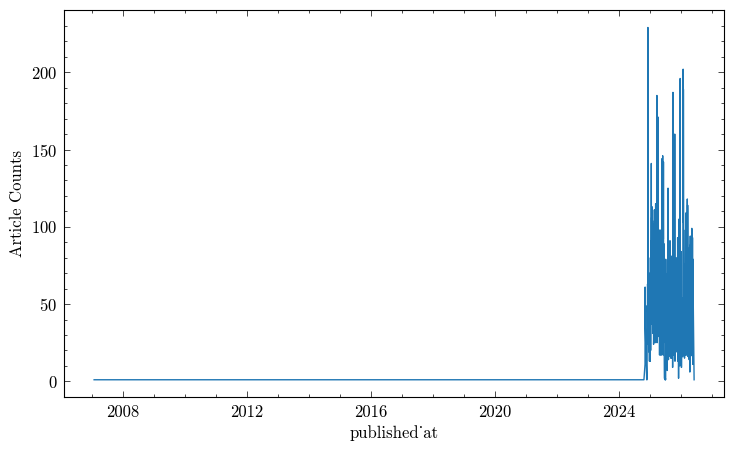

In [91]:
plt.figure(figsize=(8, 5))
daily_counts.plot()

plt.ylabel('Article Counts')

In [92]:
from collections import Counter
import json

org_counter = Counter()

for metadata in df["metadata"].dropna():
    try:
        data = json.loads(metadata) if isinstance(metadata, str) else metadata

        organizations = data.get("organizations", [])

        if organizations:
            org_counter.update(organizations)

    except Exception:
        continue

top_orgs = (
    pd.DataFrame(
        org_counter.most_common(50),
        columns=["organization", "count"]
    )
)

print(top_orgs)

               organization  count
0               duke energy    971
1          consumers energy    730
2                   entergy    624
3               xcel energy    589
4        centerpoint energy    281
5            alliant energy    115
6   american electric power     90
7          southern company     53
8        great river energy     14
9                dte energy     12
10          dairyland power      5


### Scraped Articles

In [125]:
data_path = (
    ROOT
    / "data"
    / "silver"
    / "source=gdelt"
    / "articles.parquet"
)

df = pd.read_parquet(data_path)

In [126]:
df.columns

Index(['record_id', 'source', 'source_type', 'title', 'text', 'published_at',
       'retrieved_at', 'url', 'region', 'categories', 'metadata', 'raw',
       'success', 'scrape_status', 'status_code', 'error_type',
       'error_message', 'fetch_method', 'fallback_used', 'extractor', 'author',
       'date', 'published_at_source', 'text_length', 'attempt_count'],
      dtype='object')

In [127]:
df['metadata'].iloc[0]

{'source_common_name': 'twincities.com',
 'gdelt_timestamp': '20250409144500',
 'gdelt_date': '20250409144500',
 'page_precise_pub_timestamp': '20070125000000',
 'has_precise_published_at': True,
 'published_at_source': 'source_record',
 'published_at_precision': 'second',
 'organizations': array(['xcel energy', 'parker hughes cancer center'], dtype=object),
 'persons': array(['robert spande', 'nancy dvorak', 'fatih uckun', 'parker hughe',
        'jeremy olson', 'kenneth corey-edstrom', 'parker hughes'],
       dtype=object),
 'locations': array(['US-USIL', 'USMN', 'USIL', 'US', 'US-USMN'], dtype=object),
 'tone': '-3.36134453781513,2.01680672268908,5.3781512605042,7.39495798319328,22.3529411764706,0.840336134453782,513',
 'theme_match': False,
 'organization_match': True,
 'location_match': True,
 'filter_match_count': None,
 'original_published_at': '2007-01-25T00:00:00+00:00',
 'scraped_published_at': '2007-01-25T00:00:00+00:00',
 'final_published_at': '2007-01-25T00:00:00+00:00',


In [128]:
df["has_precise_published_at"] = df["metadata"].apply(
    lambda x: x.get("has_precise_published_at", False)
)
df["precise_published_at_source"] = df["metadata"].apply(
    lambda x: x.get("published_at_source", None)
)

In [129]:
df["has_precise_published_at"].mean()

np.float64(1.0)

In [130]:
df.loc[df['has_precise_published_at'], 'precise_published_at_source'].value_counts()

precise_published_at_source
source_record    29840
Name: count, dtype: int64

In [97]:
df['published_at'].min()

'01/02/2026 14:00:47'

In [98]:
df['published_at'].max()

'Wednesday,24 June 2026-09 Muharram 1448 AH'

In [99]:
(
    df["success"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

success
True     71.44
False    28.56
Name: proportion, dtype: float64

In [100]:
(
    (df["scrape_status"].value_counts() / len(df))
    .mul(100)
    .round(2)
)

scrape_status
success               71.44
not_found             11.53
rate_limited           5.19
unknown                3.77
server_error           3.12
playwright_timeout     1.55
client_error           1.55
parse_failed           1.24
connection_error       0.44
http_error             0.16
Name: count, dtype: float64

In [101]:
(
    df.groupby("error_type")
      .size()
      .sort_values(ascending=False)
)

error_type
not_found             3441
rate_limited          1548
unknown               1125
server_error           931
playwright_timeout     463
client_error           462
parse_failed           371
connection_error       132
http_error              48
dtype: int64

In [102]:
(
    df.groupby("status_code")
      .size()
      .sort_values(ascending=False)
)

status_code
200.0    20592
404.0     3521
429.0     1548
403.0      958
526.0      908
307.0       36
410.0       29
406.0       24
202.0       19
500.0       18
521.0        4
502.0        1
dtype: int64

In [103]:
df["text_length"].describe()

count    29840.000000
mean      2601.703184
std       2650.519976
min          0.000000
25%          0.000000
50%       1855.000000
75%       4504.250000
max       8000.000000
Name: text_length, dtype: float64

In [104]:
from urllib.parse import urlparse

df["domain"] = (
    df["url"]
    .apply(lambda x: urlparse(x).netloc)
)

In [105]:
(
    df.groupby("domain")["success"]
      .mean()
      .sort_values()
)

domain
www.citynewsokc.com        0.0
www.deadlinedetroit.com    0.0
www.coastreporter.net      0.0
www.clevelandstar.com      0.0
www.dailygazette.com       0.0
                          ... 
yooper.fm                  1.0
yorknewstimes.com          1.0
yourdemocracy.net          1.0
1025kiss.com               1.0
1019bigwaax.iheart.com     1.0
Name: success, Length: 2479, dtype: float64

In [106]:
(
    df.groupby("domain")
      .size()
      .sort_values(ascending=False)
      .head(30)
)

domain
www.yahoo.com                   1511
www.themarketsdaily.com          846
www.dailypolitical.com           778
www.tickerreport.com             653
finance.yahoo.com                463
www.marketscreener.com           460
www.prnewswire.com               338
www.modernreaders.com            333
theenterpriseleader.com          332
www.nola.com                     247
www.wkrb13.com                   243
www.mlive.com                    232
www.fool.com                     228
markets.financialcontent.com     211
www.utilitydive.com              209
www.insidermonkey.com            177
wwmt.com                         167
www.wnem.com                     166
www.wwltv.com                    155
www.theadvocate.com              155
www.wsoctv.com                   153
www.denverpost.com               148
www.wzzm13.com                   143
www.renewableenergyworld.com     142
www.wbrz.com                     139
www.finanznachrichten.de         138
www.wfae.org                   

In [107]:
sample = (
    df[df["success"]]
    .sample(50, random_state=42)
)

In [108]:
sample['text']

16518    Country United States of America US Virgin Isl...
15815    Access Denied You don't have permission to acc...
27290    Company to build 260 MW BESS to meet growing e...
1608     US utility Alliant Energy has completed constr...
29088    Bills are about to go up again for Appalachian...
17940    By MATTHEW DALY, Associated Press WASHINGTON (...
15141    by Brian Martucci, Minnesota Reformer Private ...
9321     With future funding of Colorado’s water projec...
9076     Last week, Missouri governor Mike Kehoe signed...
4686     Rebecca J. Roeker of Attolles Law attended the...
26499    Consumers Energy mobilizes crews to restore po...
8308     Utility profits grow along with anti-rooftop s...
13022    *This story was updated at 10:26 p.m., July 7,...
20894    The following list includes recent reports fro...
20241    Xcel’s rate increases are no coincidence I fin...
533      BURLINGTON — Firefighters rescued a goldfish f...
27026    By Alex Brown, Stateline.org In an unprecedent.

## IEM AFOS

In [109]:
data_path = (
    ROOT
    / "data"
    / "silver"
    / "source=iem_afos"
    / "records.parquet"
)

df = pd.read_parquet(data_path)

In [110]:
df.columns

Index(['record_id', 'source', 'source_type', 'title', 'text', 'published_at',
       'retrieved_at', 'url', 'region', 'categories', 'metadata', 'raw'],
      dtype='object')

In [111]:
df.iloc[0]

record_id       4b8ac526c396cf72436a0d18c06354726d8985c8ec407e...
source                                                   iem_afos
source_type                                                   api
title           AFD | KIWX | Issued at 208 PM EST Sat Nov 30 2024
text            - Scattered lake effect snow showers over sout...
published_at                            2024-11-30T19:08:00+00:00
retrieved_at                     2026-06-22T16:31:05.531700+00:00
url             https://mesonet.agron.iastate.edu/cgi-bin/afos...
region                                                        IWX
categories                         [weather, nws, iem, afos, afd]
metadata        {'pil': 'AFDIWX', 'product_type': 'AFD', 'offi...
raw             564 \nFXUS63 KIWX 010522\nAFDIWX\n\nArea Forec...
Name: 0, dtype: object

In [112]:
df["metadata"].iloc[0]

{'pil': 'AFDIWX',
 'product_type': 'AFD',
 'office': 'KIWX',
 'sections': {'KEY MESSAGES': '- Scattered lake effect snow showers over southern Michigan will\n  become more numerous into Monday as they spread south into\n  northern Indiana.\n\n- Unseasonable cold continues through the week with highs\n  ranging from the upper 20s to low 30s with lows in the teens.',
  'DISCUSSION': 'Issued at 208 PM EST Sat Nov 30 2024\n\nPersisting neg height anomaly over ern Canada keeps an influx of \ncold, dry modified arctic air in place through the period. Bouts of \nlake effect, primarily confined to southern Michigan, are expected \nat times timed with generally weak disturbances embedded within \nsteep northwest flow aloft across the lakes/New England. \n\nWave disturbance over nrn BC this aftn will sharpen a bit as it \ndives sewd into the wrn OH valley by Mon. Somewhat better low level \nveering progged which will support a more robust but likely \nsmall/confined lake response within the ern 

In [113]:
df["source"].value_counts()

source
iem_afos    39294
Name: count, dtype: int64

In [114]:
df["product_type"] = df["metadata"].apply(
    lambda x: x.get("product_type")
)

df["product_type"].value_counts()

product_type
AFD    14487
LSR     9926
HWO     8312
SPS     3076
NPW     2485
WSW     1008
Name: count, dtype: int64

In [115]:
df["region"].value_counts()

region
LOT    5980
ILX    5960
IND    5955
DVN    5854
DMX    5427
IWX    5148
LSX    4970
Name: count, dtype: int64

In [116]:
(
    df.groupby(
        [
            pd.to_datetime(df["published_at"]).dt.date,
            "region"
        ]
    )
    .size()
    .unstack(fill_value=0)
)

region,DMX,DVN,ILX,IND,IWX,LOT,LSX
published_at,,,,,,,
2024-11-30,1,2,0,0,1,1,1
2024-12-01,8,9,19,17,12,8,93
2024-12-02,33,34,15,12,25,8,26
2024-12-03,10,11,9,11,21,10,9
2024-12-04,16,19,10,16,11,15,10
...,...,...,...,...,...,...,...
2026-06-14,9,8,8,14,15,14,6
2026-06-15,8,7,8,12,9,12,7
2026-06-16,10,9,9,32,38,19,7


In [117]:
df["text_length"] = (
    df["text"]
    .fillna("")
    .str.len()
)

(
    df.groupby("product_type")["text_length"]
      .describe()
)

,count,mean,std,min,25%,50%,75%,max
product_type,,,,,,,,
AFD,14487.0,971.859667,1101.790630,53.0,304.00,455.0,1347.0,8000.0
HWO,8312.0,1685.388114,792.896181,285.0,1197.75,1480.0,1945.0,8000.0
LSR,9926.0,589.275438,921.492570,330.0,368.00,397.0,447.0,8000.0
NPW,2485.0,1997.086117,1119.979527,321.0,1208.00,1750.0,2512.0,8000.0
SPS,3076.0,1302.420026,384.158267,477.0,1055.75,1258.0,1480.0,5783.0
WSW,1008.0,2525.853175,1519.523900,432.0,1340.00,2253.5,3325.0,8000.0


In [118]:
weather_terms = [
    "snow",
    "ice",
    "lake effect",
    "thunderstorm",
    "tornado",
    "wind",
    "heat",
    "cold",
    "rain",
    "flood"
]

for term in weather_terms:
    count = (
        df["text"]
        .str.lower()
        .str.contains(term, na=False)
        .sum()
    )

    print(term, count)

snow 9753
ice 26041
lake effect 977
thunderstorm 11023
tornado 2087
wind 16526
heat 3894
cold 7169
rain 14660
flood 3912


In [119]:
winter_terms = (
    df["text"]
    .str.lower()
    .str.contains(
        "snow|ice|blizzard|freezing",
        regex=True,
        na=False,
    )
)

summer_terms = (
    df["text"]
    .str.lower()
    .str.contains(
        "heat|thunderstorm",
        regex=True,
        na=False,
    )
)

In [120]:
monthly = (
    df.assign(
        winter=winter_terms,
        summer=summer_terms,
        month=pd.to_datetime(df["published_at"]).dt.month,
    )
    .groupby("month")[["winter", "summer"]]
    .sum()
)

print(monthly)

       winter  summer
month                
1        3875     340
2        3302     547
3        3719    1661
4        2866    1953
5        2265    1666
6        3622    2374
7        2017    1730
8        1302     981
9         722     725
10        785     394
11       1156     230
12       4336     340


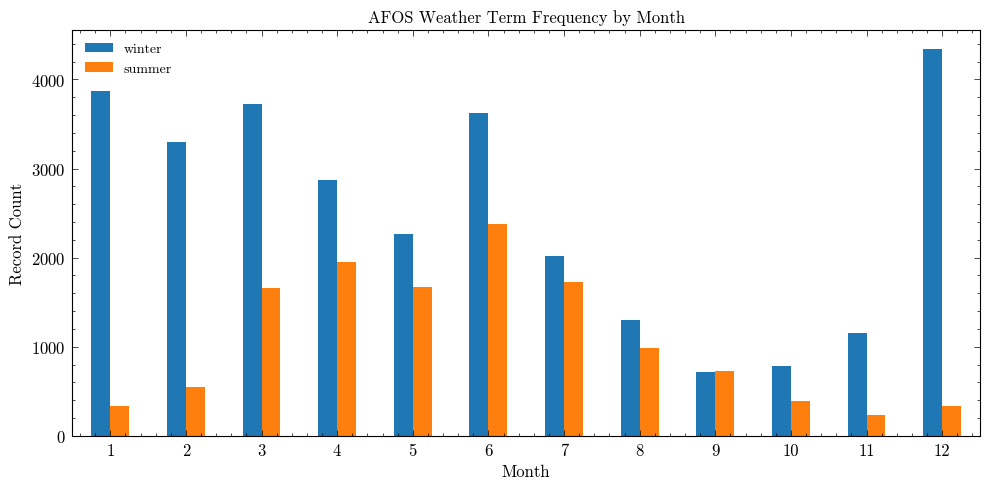

In [121]:
import matplotlib.pyplot as plt

monthly.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("AFOS Weather Term Frequency by Month")
plt.ylabel("Record Count")
plt.xlabel("Month")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()